## **Libraries and imports**

## **Google Colab setup**

In [ ]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger')
nltk.download('maxent_ne_chunker')
nltk.download('maxent_ne_chunker_tab')
nltk.download('words')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package maxent_ne_chunker is already up-to-date!
[nltk_data] Downloading package maxent_ne_chunker_tab to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package maxent_ne_chunker_tab is already up-to-date!
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Package words is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to

True

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import re
import matplotlib.pyplot as plt
from nltk.tokenize import sent_tokenize
from nltk import pos_tag, word_tokenize
from nltk import ne_chunk
from sklearn.decomposition import PCA
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

## **Tokenization & Cleaning**

In [ ]:
data = pd.read_csv("data.csv")
analysis_data = data.copy()


In [ ]:
data.head()

,label,input
0,cervical spondylosis,I've been having a lot of pain in my neck and ...
1,impetigo,I have a rash on my face that is getting worse...
2,urinary tract infection,I have been urinating blood. I sometimes feel ...
3,arthritis,I have been having trouble with my muscles and...
4,dengue,I have been feeling really sick. My body hurts...


In [ ]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\n', ' ', text)
    text = re.sub(r'[^a-zA-Z0-9\s\.]', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

data['input'] = data['input'].apply(clean_text)

In [ ]:
data

,label,input
0,cervical spondylosis,ive been having a lot of pain in my neck and b...
1,impetigo,i have a rash on my face that is getting worse...
2,urinary tract infection,i have been urinating blood. i sometimes feel ...
3,arthritis,i have been having trouble with my muscles and...
4,dengue,i have been feeling really sick. my body hurts...
...,...,...
1983,diabetes,im shaking and trembling all over. ive lost my...
1984,diabetes,particularly in the crevices of my skin i have...
1985,diabetes,i regularly experience these intense urges and...
1986,diabetes,i have trouble breathing especially outside. i...


In [ ]:
def nltk_preprocess_pipeline(text):
        words = word_tokenize(text)
        stop_words = set(stopwords.words('english'))
        words = [w.lower() for w in words if w.lower() not in stop_words and w.isalpha()]
        tokens = words
        return tokens


In [ ]:
data['processed'] = data['input'].apply(nltk_preprocess_pipeline)
data['processed'] = data['processed'].apply(lambda x: " ".join(x))
data['processed_tokens'] = data['processed'].apply(lambda x: x.split())

In [ ]:
data

,label,input,processed,processed_tokens
0,cervical spondylosis,ive been having a lot of pain in my neck and b...,ive lot pain neck back ive also trouble balanc...,"[ive, lot, pain, neck, back, ive, also, troubl..."
1,impetigo,i have a rash on my face that is getting worse...,rash face getting worse red inflamed blisters ...,"[rash, face, getting, worse, red, inflamed, bl..."
2,urinary tract infection,i have been urinating blood. i sometimes feel ...,urinating blood sometimes feel sick stomach ur...,"[urinating, blood, sometimes, feel, sick, stom..."
3,arthritis,i have been having trouble with my muscles and...,trouble muscles joints neck really tight muscl...,"[trouble, muscles, joints, neck, really, tight..."
4,dengue,i have been feeling really sick. my body hurts...,feeling really sick body hurts lot appetite al...,"[feeling, really, sick, body, hurts, lot, appe..."
...,...,...,...,...
1983,diabetes,im shaking and trembling all over. ive lost my...,im shaking trembling ive lost sense taste smel...,"[im, shaking, trembling, ive, lost, sense, tas..."
1984,diabetes,particularly in the crevices of my skin i have...,particularly crevices skin skin rashes irritat...,"[particularly, crevices, skin, skin, rashes, i..."
1985,diabetes,i regularly experience these intense urges and...,regularly experience intense urges want urinat...,"[regularly, experience, intense, urges, want, ..."
1986,diabetes,i have trouble breathing especially outside. i...,trouble breathing especially outside start fee...,"[trouble, breathing, especially, outside, star..."


## **Analyzing data**

In [ ]:
analysis_data['input'] = analysis_data['input'].apply(clean_text)
analysis_data['processed'] = analysis_data['input'].apply(nltk_preprocess_pipeline)
analysis_data['processed'] = analysis_data['processed'].apply(lambda x: " ".join(x))
analysis_data['processed_tokens'] = analysis_data['processed'].apply(lambda x: x.split())

In [ ]:
label_counts = analysis_data['label'].value_counts()

print(label_counts)

label
impetigo                           90
diabetes                           90
psoriasis                          90
urinary tract infection            89
varicose veins                     89
allergy                            89
drug reaction                      89
hypertension                       89
chicken pox                        89
common cold                        88
typhoid                            88
bronchial asthma                   88
cervical spondylosis               87
fungal infection                   87
dengue                             87
peptic ulcer disease               86
gastroesophageal reflux disease    86
arthritis                          84
malaria                            84
pneumonia                          84
migraine                           79
jaundice                           69
acne                               46
dimorphic hemorrhoids              41
Name: count, dtype: int64


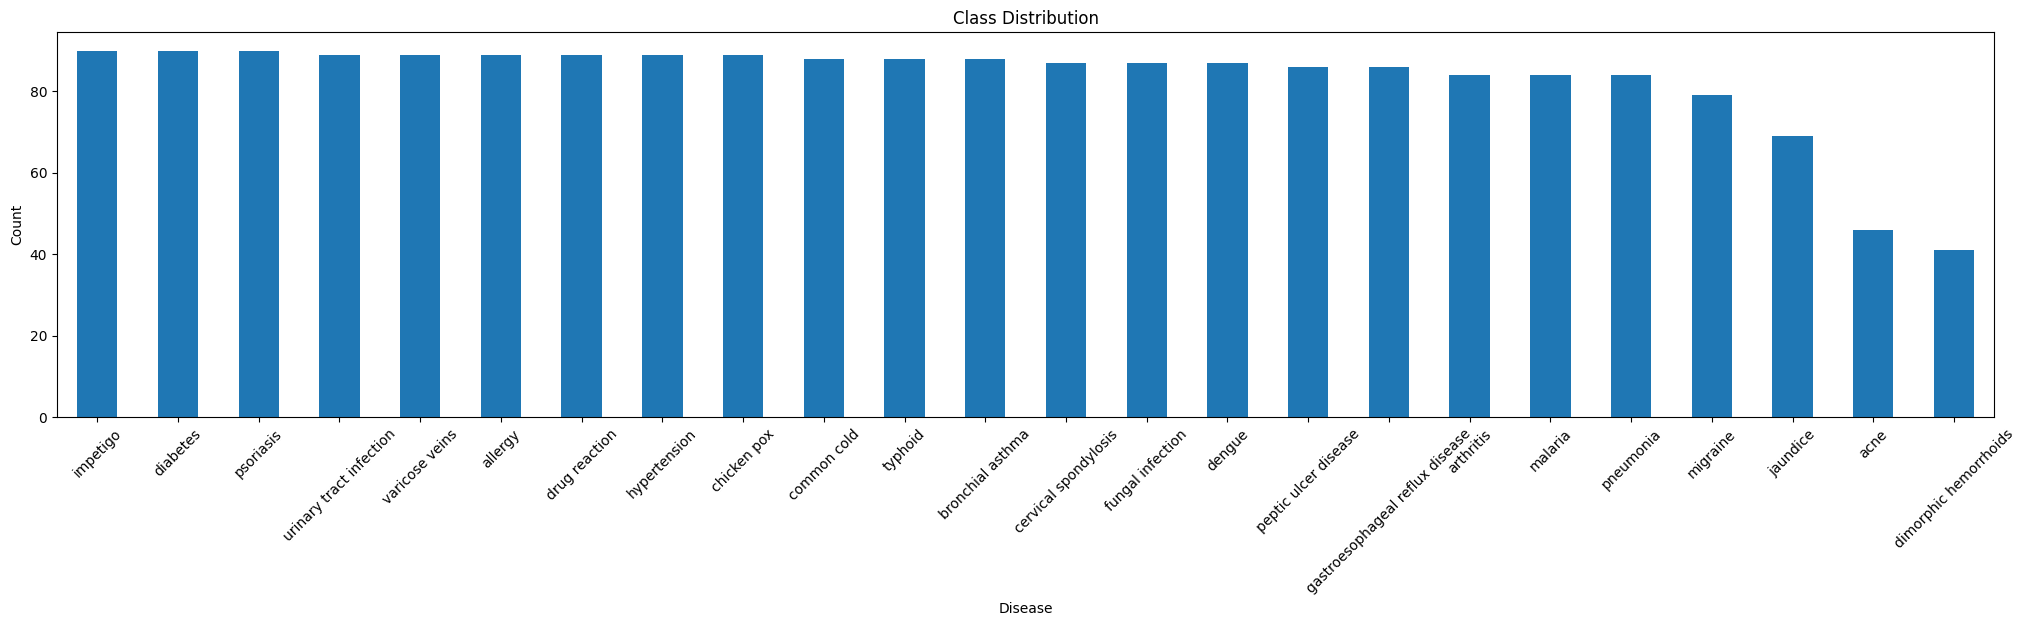

In [ ]:
plt.figure(figsize=(25,5))
label_counts.plot(kind='bar')
plt.title("Class Distribution")
plt.xlabel("Disease")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [ ]:
analysis_data

,label,input,processed,processed_tokens
0,cervical spondylosis,ive been having a lot of pain in my neck and b...,ive lot pain neck back ive also trouble balanc...,"[ive, lot, pain, neck, back, ive, also, troubl..."
1,impetigo,i have a rash on my face that is getting worse...,rash face getting worse red inflamed blisters ...,"[rash, face, getting, worse, red, inflamed, bl..."
2,urinary tract infection,i have been urinating blood. i sometimes feel ...,urinating blood sometimes feel sick stomach ur...,"[urinating, blood, sometimes, feel, sick, stom..."
3,arthritis,i have been having trouble with my muscles and...,trouble muscles joints neck really tight muscl...,"[trouble, muscles, joints, neck, really, tight..."
4,dengue,i have been feeling really sick. my body hurts...,feeling really sick body hurts lot appetite al...,"[feeling, really, sick, body, hurts, lot, appe..."
...,...,...,...,...
1983,diabetes,im shaking and trembling all over. ive lost my...,im shaking trembling ive lost sense taste smel...,"[im, shaking, trembling, ive, lost, sense, tas..."
1984,diabetes,particularly in the crevices of my skin i have...,particularly crevices skin skin rashes irritat...,"[particularly, crevices, skin, skin, rashes, i..."
1985,diabetes,i regularly experience these intense urges and...,regularly experience intense urges want urinat...,"[regularly, experience, intense, urges, want, ..."
1986,diabetes,i have trouble breathing especially outside. i...,trouble breathing especially outside start fee...,"[trouble, breathing, especially, outside, star..."


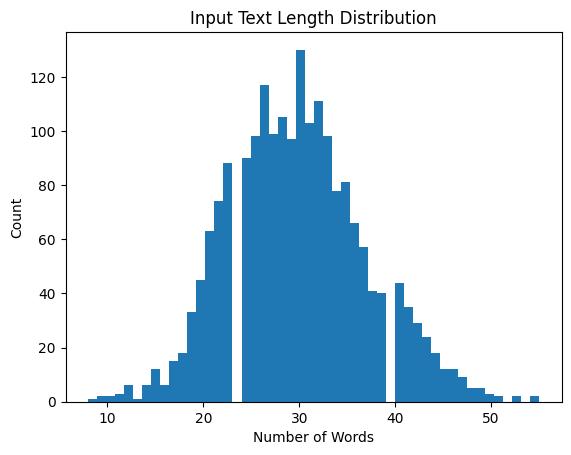

In [ ]:
analysis_data['input_length'] = analysis_data['input'].apply(lambda x: len(x.split()))

plt.hist(analysis_data['input_length'], bins=50)
plt.title("Input Text Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Count")
plt.show()

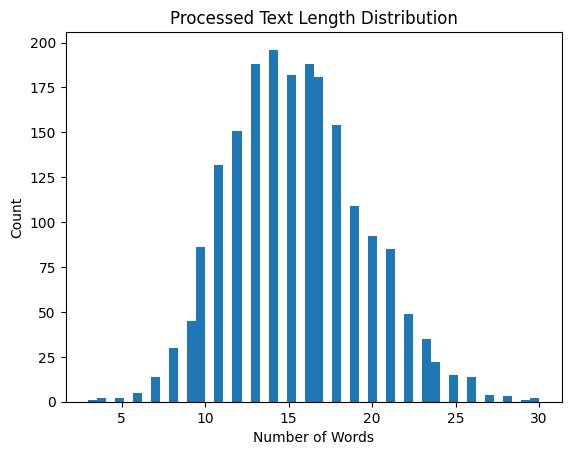

In [ ]:
analysis_data['processed_input_length'] = analysis_data['processed'].apply(lambda x: len(x.split()))

plt.hist(analysis_data['processed_input_length'], bins=50)
plt.title("Processed Text Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Count")
plt.show()

In [ ]:
print(analysis_data['input'][0])
print(analysis_data['processed'][0])

ive been having a lot of pain in my neck and back. ive also been having trouble with my balance and coordination. ive been coughing a lot and my limbs feel weak.
ive lot pain neck back ive also trouble balance coordination ive coughing lot limbs feel weak


In [ ]:
analysis_data['mean_word_processed'] = analysis_data['processed'].map(lambda rev: np.mean([len(word) for word in rev.split()]))
analysis_data.head(10)


,label,input,processed,processed_tokens,input_length,processed_input_length,mean_word_processed
0,cervical spondylosis,ive been having a lot of pain in my neck and b...,ive lot pain neck back ive also trouble balanc...,"[ive, lot, pain, neck, back, ive, also, troubl...",32,16,4.875000
1,impetigo,i have a rash on my face that is getting worse...,rash face getting worse red inflamed blisters ...,"[rash, face, getting, worse, red, inflamed, bl...",27,12,5.666667
2,urinary tract infection,i have been urinating blood. i sometimes feel ...,urinating blood sometimes feel sick stomach ur...,"[urinating, blood, sometimes, feel, sick, stom...",23,11,5.727273
3,arthritis,i have been having trouble with my muscles and...,trouble muscles joints neck really tight muscl...,"[trouble, muscles, joints, neck, really, tight...",41,21,5.904762
4,dengue,i have been feeling really sick. my body hurts...,feeling really sick body hurts lot appetite al...,"[feeling, really, sick, body, hurts, lot, appe...",34,16,4.937500
5,common cold,ive been feeling really run down and weak. my ...,ive feeling really run weak throat sore ive co...,"[ive, feeling, really, run, weak, throat, sore...",26,14,4.642857
6,dengue,i have rashes all over my body. i also have a ...,rashes body also high fever chills headache bo...,"[rashes, body, also, high, fever, chills, head...",22,12,5.000000
7,dengue,i have been feeling nauseous and have a consta...,feeling nauseous constant urge vomit accompani...,"[feeling, nauseous, constant, urge, vomit, acc...",27,13,5.923077
8,impetigo,i have a rash around my nose that is red and i...,rash around nose red inflamed rash caused skin...,"[rash, around, nose, red, inflamed, rash, caus...",35,16,5.125000
9,drug reaction,i have a rash on my chest and back and it itch...,rash chest back itches also dry skin sometimes...,"[rash, chest, back, itches, also, dry, skin, s...",26,12,5.000000


In [ ]:
from collections import Counter

all_words = []

for text in analysis_data['processed']:
    all_words.extend(text.split())

word_counts = Counter(all_words)

print(word_counts.most_common(20))

[('ive', 1235), ('also', 916), ('lot', 690), ('really', 652), ('skin', 558), ('pain', 513), ('im', 509), ('feeling', 453), ('fever', 431), ('feel', 418), ('neck', 281), ('high', 270), ('chest', 261), ('get', 246), ('experiencing', 242), ('hurts', 225), ('cough', 225), ('headache', 224), ('red', 218), ('throat', 217)]


In [ ]:
from nltk import tokenize
analysis_data['mean_input_length'] = analysis_data['input'].map(lambda rev: np.mean([len(sent) for sent in tokenize.sent_tokenize(rev)]))
analysis_data.head(10)

,label,input,processed,processed_tokens,input_length,processed_input_length,mean_word_processed,mean_input_length
0,cervical spondylosis,ive been having a lot of pain in my neck and b...,ive lot pain neck back ive also trouble balanc...,"[ive, lot, pain, neck, back, ive, also, troubl...",32,16,4.875000,53.000000
1,impetigo,i have a rash on my face that is getting worse...,rash face getting worse red inflamed blisters ...,"[rash, face, getting, worse, red, inflamed, bl...",27,12,5.666667,44.000000
2,urinary tract infection,i have been urinating blood. i sometimes feel ...,urinating blood sometimes feel sick stomach ur...,"[urinating, blood, sometimes, feel, sick, stom...",23,11,5.727273,37.333333
3,arthritis,i have been having trouble with my muscles and...,trouble muscles joints neck really tight muscl...,"[trouble, muscles, joints, neck, really, tight...",41,21,5.904762,54.500000
4,dengue,i have been feeling really sick. my body hurts...,feeling really sick body hurts lot appetite al...,"[feeling, really, sick, body, hurts, lot, appe...",34,16,4.937500,38.750000
5,common cold,ive been feeling really run down and weak. my ...,ive feeling really run weak throat sore ive co...,"[ive, feeling, really, run, weak, throat, sore...",26,14,4.642857,42.666667
6,dengue,i have rashes all over my body. i also have a ...,rashes body also high fever chills headache bo...,"[rashes, body, also, high, fever, chills, head...",22,12,5.000000,53.500000
7,dengue,i have been feeling nauseous and have a consta...,feeling nauseous constant urge vomit accompani...,"[feeling, nauseous, constant, urge, vomit, acc...",27,13,5.923077,72.500000
8,impetigo,i have a rash around my nose that is red and i...,rash around nose red inflamed rash caused skin...,"[rash, around, nose, red, inflamed, rash, caus...",35,16,5.125000,83.000000
9,drug reaction,i have a rash on my chest and back and it itch...,rash chest back itches also dry skin sometimes...,"[rash, chest, back, itches, also, dry, skin, s...",26,12,5.000000,60.000000


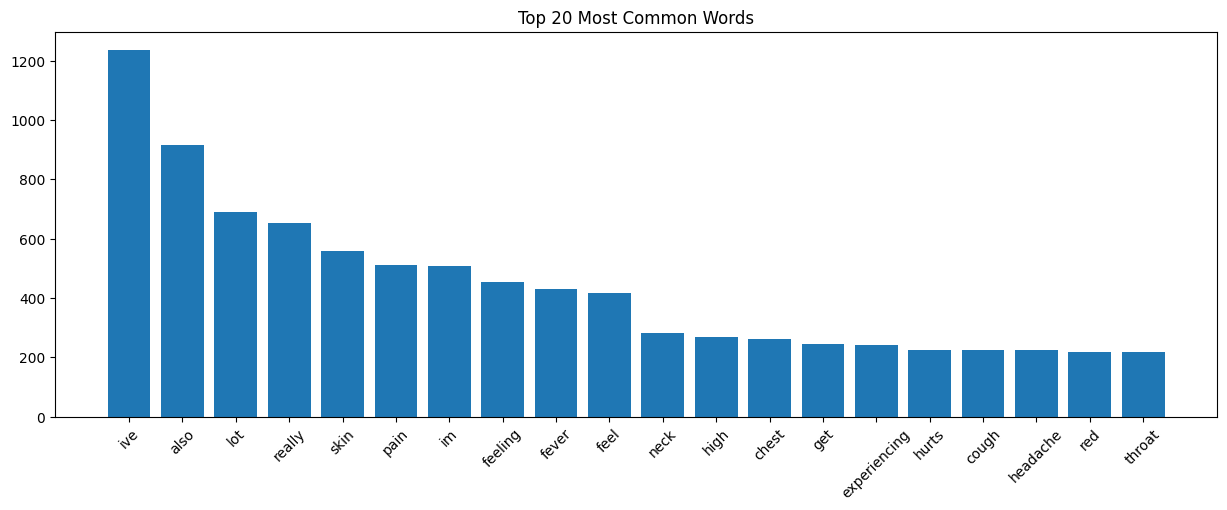

In [ ]:
common_words = word_counts.most_common(20)

words = [w[0] for w in common_words]
counts = [w[1] for w in common_words]


plt.figure(figsize=(15,5))
plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title("Top 20 Most Common Words")
plt.show()

In [ ]:
for disease in analysis_data['label'].unique():
    texts = analysis_data[analysis_data['label'] == disease]['processed']

    words = []
    for t in texts:
        words.extend(t.split())

    print(f"\nTop words for {disease}:")
    print(Counter(words).most_common(10))


Top words for cervical spondylosis:
[('pain', 88), ('neck', 87), ('ive', 85), ('back', 79), ('cough', 65), ('hurts', 52), ('weakness', 50), ('balance', 36), ('also', 33), ('arms', 33)]

Top words for impetigo:
[('sores', 89), ('nose', 58), ('rash', 55), ('face', 50), ('painful', 41), ('red', 37), ('fever', 37), ('yellow', 28), ('fluid', 26), ('near', 26)]

Top words for urinary tract infection:
[('pee', 76), ('urine', 45), ('urinate', 37), ('ive', 37), ('get', 37), ('blood', 33), ('also', 31), ('sometimes', 29), ('hurts', 26), ('smells', 25)]

Top words for arthritis:
[('joints', 86), ('stiff', 82), ('neck', 77), ('walking', 59), ('really', 57), ('muscles', 56), ('ive', 49), ('weak', 47), ('move', 47), ('also', 45)]

Top words for dengue:
[('pain', 58), ('fever', 40), ('feel', 40), ('also', 39), ('body', 35), ('back', 33), ('red', 32), ('arms', 28), ('spots', 28), ('experiencing', 26)]

Top words for common cold:
[('ive', 123), ('really', 87), ('lot', 79), ('throat', 51), ('nose', 50)

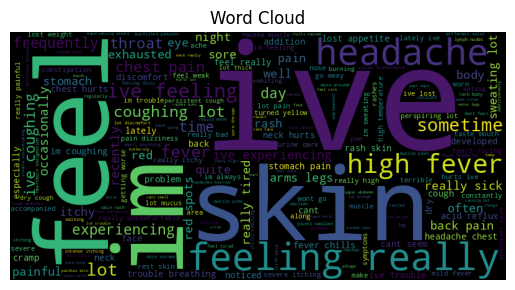

In [ ]:
from wordcloud import WordCloud

text = " ".join(data['processed'])

wordcloud = WordCloud(width=800, height=400).generate(text)

plt.imshow(wordcloud)
plt.axis("off")
plt.title("Word Cloud")
plt.show()

## **Embeddings**

In [ ]:
!pip install gensim transformers wordcloud -q

from gensim.models import Word2Vec

w2v_model = Word2Vec(
    sentences=data['processed_tokens'],
    vector_size=100,
    window=5,
    min_count=2,
    sg=0,
    epochs=10
)

w2v_model.save("symptom_word2vec.model")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 77.2 MB/s eta 0:00:00


In [ ]:
from gensim.models import FastText

ft_model = FastText(
    sentences=data['processed_tokens'],
    vector_size=100,
    window=5,
    min_count=2,
    sg=0,
    epochs=10
)

ft_model.save("symptom_fasttext.model")

In [ ]:
print("Word2Vec:", "fever" in w2v_model.wv.key_to_index)
print("FastText:", ft_model.wv['fever'][:10])

Word2Vec: True
FastText: [ 0.13528748  0.3385242  -0.45814723  0.46801388  0.27676603  0.07985757
  0.18907642  0.32677796 -0.2735857   0.10662447]


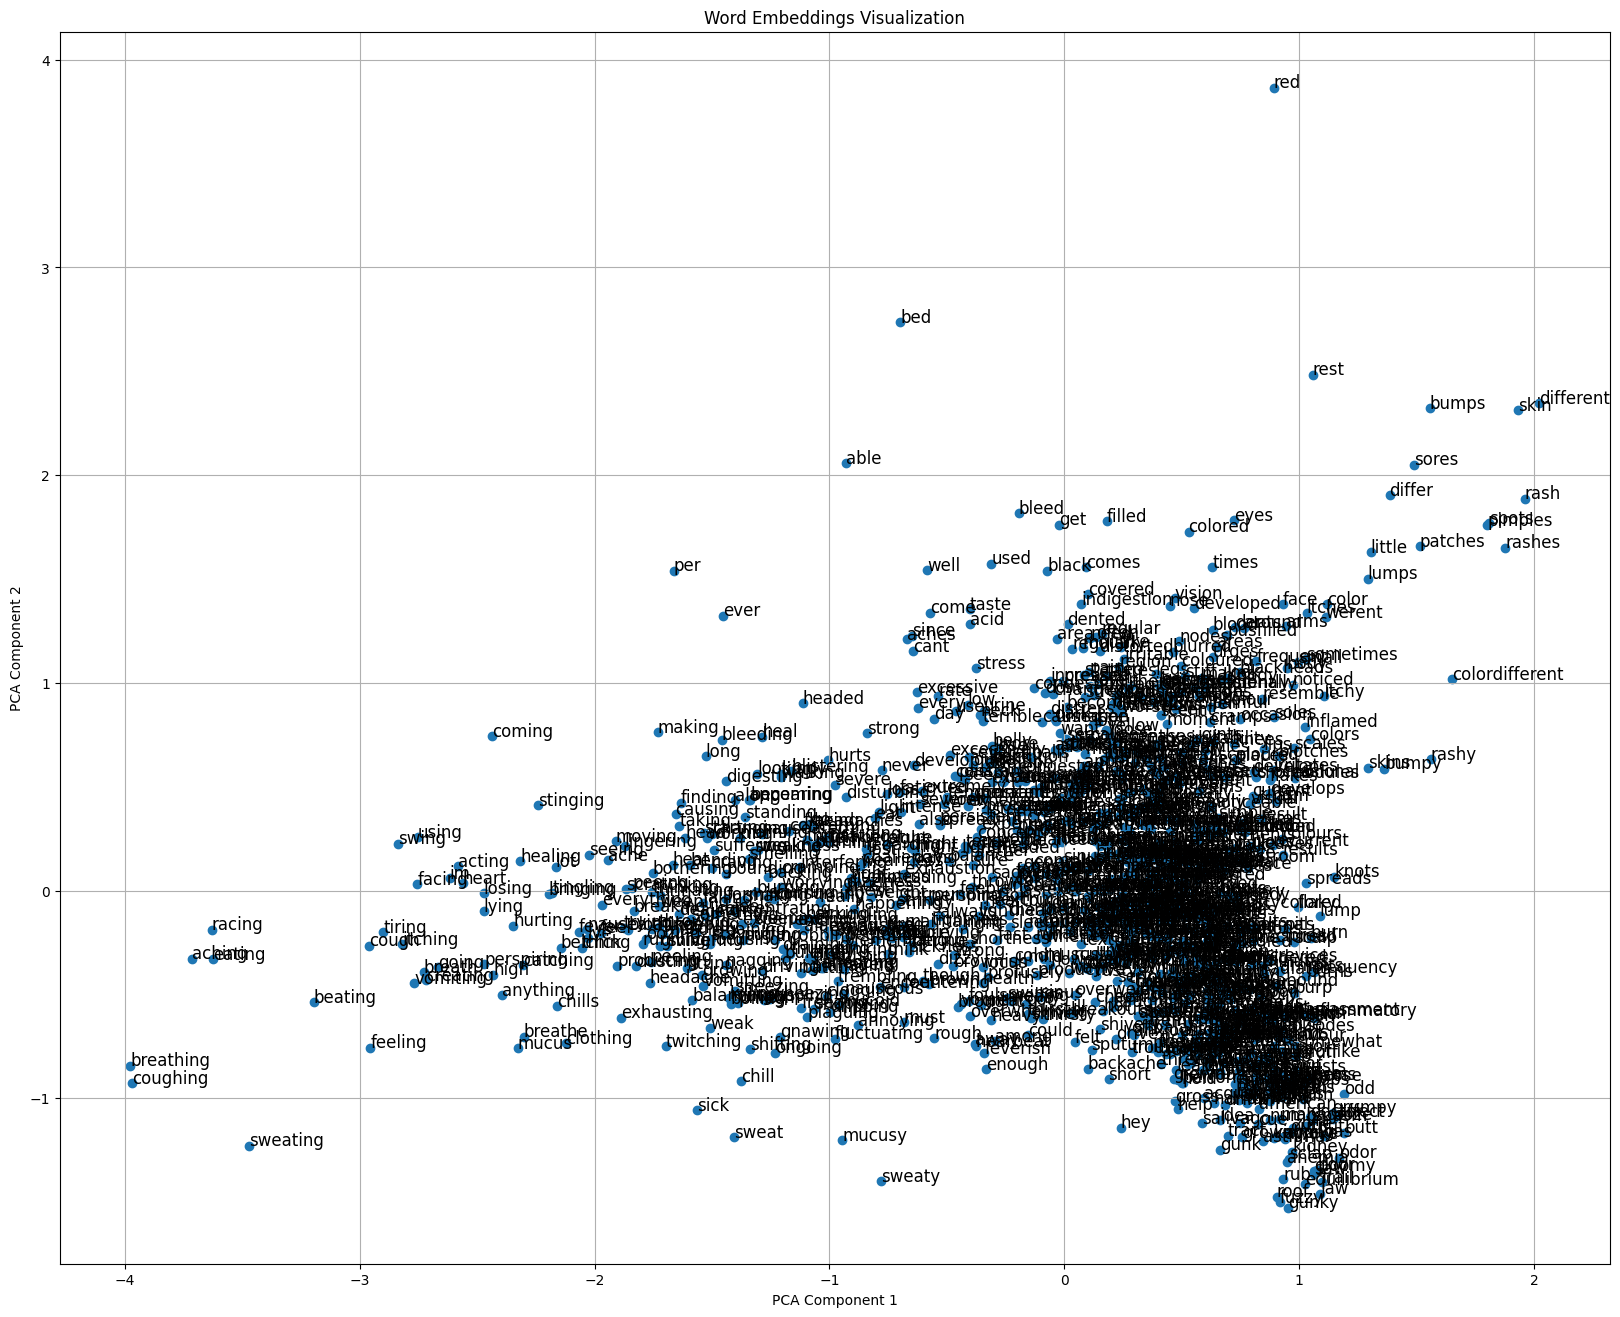

In [ ]:
word_vectors = ft_model.wv[ft_model.wv.index_to_key]
pca = PCA(n_components=2)
result = pca.fit_transform(word_vectors)

plt.figure(figsize=(20, 16))
plt.scatter(result[:, 0], result[:, 1])

words = list(ft_model.wv.index_to_key)
for i, word in enumerate(words):
    plt.annotate(word, xy=(result[i, 0], result[i, 1]), fontsize=12)

plt.title("Word Embeddings Visualization")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid()
plt.show()

## **Phase 2 - Model Selection, Training and Evaluation**

In this phase, we will do two things.

1. Improve the two original models using simple methods that follow the project requirements: better input preparation, class-weighted loss, stronger dropout, and early stopping.
2. Add two stronger medical-domain transformer models and compare them with the improved base models.

The four models in this notebook are:
- `BiLSTM + FastText (Improved)`
- `DistilBERT (Improved)`
- `Bio_ClinicalBERT`
- `BiomedBERT`

In [ ]:
pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 38.3 MB/s eta 0:00:00


In [ ]:
import random
import copy
import torch
import torch.nn as nn
from collections import Counter
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import Dataset, DataLoader, TensorDataset
from gensim.models import FastText
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from tqdm.auto import tqdm

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

if torch.backends.cudnn.is_available():
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


## **Preparing the data**

In [ ]:
phase2_source = pd.read_csv("data.csv").copy()


phase2_data = phase2_source[['input', 'label']].copy()
phase2_data['clean_input'] = phase2_data['input'].apply(clean_text)
phase2_data['processed_tokens'] = phase2_data['clean_input'].apply(nltk_preprocess_pipeline)
phase2_data['processed_text'] = phase2_data['processed_tokens'].apply(lambda x: " ".join(x))
phase2_data = phase2_data[phase2_data['processed_text'].str.len() > 0].reset_index(drop=True)

phase2_data.head()

FileNotFoundError: [Errno 2] No such file or directory: 'data.csv'

In [ ]:
label_encoder = LabelEncoder()
phase2_data['target'] = label_encoder.fit_transform(phase2_data['label'])

train_df, temp_df = train_test_split(
    phase2_data,
    test_size=0.30,
    random_state=42,
    stratify=phase2_data['target']
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df['target']
)

train_texts_lstm = train_df['processed_text'].tolist()
val_texts_lstm = val_df['processed_text'].tolist()
test_texts_lstm = test_df['processed_text'].tolist()

train_texts_transformer = train_df['transformer_text'].tolist()
val_texts_transformer = val_df['transformer_text'].tolist()
test_texts_transformer = test_df['transformer_text'].tolist()

test_original_texts = test_df['input'].tolist()

train_labels = train_df['target'].tolist()
val_labels = val_df['target'].tolist()
test_labels = test_df['target'].tolist()

print("Train size:", len(train_df))
print("Validation size:", len(val_df))
print("Test size:", len(test_df))
print("Number of classes:", len(label_encoder.classes_))

Train size: 1391
Validation size: 298
Test size: 299
Number of classes: 24


In [ ]:
class_weight_values = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

class_weights_tensor = torch.tensor(class_weight_values, dtype=torch.float32).to(device)

class_weight_table = pd.DataFrame({
    'Disease': label_encoder.inverse_transform(np.unique(train_labels)),
    'Train Count': train_df['label'].value_counts().reindex(label_encoder.inverse_transform(np.unique(train_labels))).values,
    'Class Weight': np.round(class_weight_values, 4)
})

class_weight_table.sort_values('Class Weight', ascending=False).head(10)

,Disease,Train Count,Class Weight
9,dimorphic hemorrhoids,29,1.9986
0,acne,32,1.8112
15,jaundice,48,1.2075
17,migraine,55,1.0538
16,malaria,59,0.9823
2,arthritis,59,0.9823
19,pneumonia,59,0.9823
18,peptic ulcer disease,60,0.9660
12,gastroesophageal reflux disease,60,0.9660
7,dengue,61,0.9501


In [ ]:


def calculate_metrics(true_labels, predicted_labels):
    accuracy = accuracy_score(true_labels, predicted_labels)

    weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(
        true_labels,
        predicted_labels,
        average='weighted',
        zero_division=0
    )

    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
        true_labels,
        predicted_labels,
        average='macro',
        zero_division=0
    )

    return {
        'Accuracy': accuracy,
        'Weighted Precision': weighted_precision,
        'Weighted Recall': weighted_recall,
        'Weighted F1': weighted_f1,
        'Macro Precision': macro_precision,
        'Macro Recall': macro_recall,
        'Macro F1': macro_f1
    }


def print_model_report(true_labels, predicted_labels, model_name):
    print(model_name)
    print(classification_report(
        true_labels,
        predicted_labels,
        target_names=label_encoder.classes_,
        zero_division=0
    ))


def plot_history(history, model_name):
    epochs = range(1, len(history['train_loss']) + 1)

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], marker='o', label='Train Loss')
    plt.plot(epochs, history['val_loss'], marker='o', label='Validation Loss')
    plt.title(f"{model_name} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['val_accuracy'], marker='o', label='Validation Accuracy')
    plt.plot(epochs, history['val_macro_f1'], marker='o', label='Validation Macro F1')
    plt.title(f"{model_name} Validation Metrics")
    plt.xlabel("Epoch")
    plt.ylabel("Score")
    plt.ylim(0, 1)
    plt.legend()

    plt.tight_layout()
    plt.show()


def show_confusion_matrix(true_labels, predicted_labels, model_name):
    cm = confusion_matrix(true_labels, predicted_labels)

    plt.figure(figsize=(16, 12))
    sns.heatmap(cm, cmap='Blues', xticklabels=False, yticklabels=False)
    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()


def get_wrong_predictions(texts, true_labels, predicted_labels, model_name, limit=10):
    wrong_rows = []

    for text, true_label, predicted_label in zip(texts, true_labels, predicted_labels):
        if true_label != predicted_label:
            wrong_rows.append({
                'Model': model_name,
                'Text': text,
                'True Label': label_encoder.inverse_transform([true_label])[0],
                'Predicted Label': label_encoder.inverse_transform([predicted_label])[0]
            })

    return pd.DataFrame(wrong_rows[:limit])

## **BiLSTM + FastText (Improved)**

Improvements used here:
- `class-weighted loss` to help smaller classes
- `dropout = 0.5`
- `early stopping` based on validation macro F1
- slightly larger FastText embeddings and a stronger training setup

In [ ]:
train_sentences = [text.split() for text in train_texts_lstm]
val_sentences = [text.split() for text in val_texts_lstm]
test_sentences = [text.split() for text in test_texts_lstm]

ft_model_phase2 = FastText(
    sentences=train_sentences,
    vector_size=150,
    window=5,
    min_count=1,
    sg=1,
    epochs=25
)

word_counter = Counter()
for sentence in train_sentences:
    word_counter.update(sentence)

word_to_index = {'<PAD>': 0, '<UNK>': 1}

for word in word_counter:
    word_to_index[word] = len(word_to_index)

max_length = int(np.percentile([len(sentence) for sentence in train_sentences], 95))
print("Maximum sequence length:", max_length)
print("Vocabulary size:", len(word_to_index))


def text_to_sequence(text, word_to_index, max_length):
    tokens = text.split()
    sequence = [word_to_index.get(token, word_to_index['<UNK>']) for token in tokens]

    if len(sequence) < max_length:
        sequence = sequence + [word_to_index['<PAD>']] * (max_length - len(sequence))
    else:
        sequence = sequence[:max_length]

    return sequence


embedding_dim = ft_model_phase2.vector_size
embedding_matrix = np.zeros((len(word_to_index), embedding_dim))

for word, index in word_to_index.items():
    if word == '<PAD>':
        continue
    if word == '<UNK>':
        embedding_matrix[index] = np.random.normal(scale=0.6, size=(embedding_dim,))
    else:
        embedding_matrix[index] = ft_model_phase2.wv[word]

X_train_lstm = np.array([text_to_sequence(text, word_to_index, max_length) for text in train_texts_lstm])
X_val_lstm = np.array([text_to_sequence(text, word_to_index, max_length) for text in val_texts_lstm])
X_test_lstm = np.array([text_to_sequence(text, word_to_index, max_length) for text in test_texts_lstm])

y_train_lstm = np.array(train_labels)
y_val_lstm = np.array(val_labels)
y_test_lstm = np.array(test_labels)

train_dataset_lstm = TensorDataset(torch.tensor(X_train_lstm, dtype=torch.long), torch.tensor(y_train_lstm, dtype=torch.long))
val_dataset_lstm = TensorDataset(torch.tensor(X_val_lstm, dtype=torch.long), torch.tensor(y_val_lstm, dtype=torch.long))
test_dataset_lstm = TensorDataset(torch.tensor(X_test_lstm, dtype=torch.long), torch.tensor(y_test_lstm, dtype=torch.long))

train_loader_lstm = DataLoader(train_dataset_lstm, batch_size=32, shuffle=True)
val_loader_lstm = DataLoader(val_dataset_lstm, batch_size=32)
test_loader_lstm = DataLoader(test_dataset_lstm, batch_size=32)

Maximum sequence length: 22
Vocabulary size: 1418


In [ ]:
class BiLSTMClassifier(nn.Module):
    def __init__(self, embedding_matrix, hidden_dim, output_dim, dropout_rate=0.5):
        super().__init__()
        self.embedding = nn.Embedding.from_pretrained(
            torch.tensor(embedding_matrix, dtype=torch.float32),
            freeze=False,
            padding_idx=0
        )
        self.lstm = nn.LSTM(
            input_size=embedding_matrix.shape[1],
            hidden_size=hidden_dim,
            batch_first=True,
            bidirectional=True
        )
        self.dropout = nn.Dropout(dropout_rate)
        self.fc = nn.Linear(hidden_dim * 2, output_dim)

    def forward(self, x):
        embedded = self.embedding(x)
        _, (hidden, _) = self.lstm(embedded)
        hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)
        output = self.dropout(hidden)
        return self.fc(output)

In [ ]:
def train_bilstm_model(model, train_loader, val_loader, epochs=12, learning_rate=0.001, patience=3):
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-5)

    history = {'train_loss': [], 'val_loss': [], 'val_accuracy': [], 'val_macro_f1': []}
    best_state = copy.deepcopy(model.state_dict())
    best_val_macro_f1 = -1
    patience_counter = 0

    for epoch in range(epochs):
        model.train()
        total_train_loss = 0

        for inputs, labels in train_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_train_loss += loss.item()

        model.eval()
        total_val_loss = 0
        val_predictions = []
        val_true_labels = []

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                outputs = model(inputs)
                loss = criterion(outputs, labels)

                total_val_loss += loss.item()

                predictions = torch.argmax(outputs, dim=1)
                val_predictions.extend(predictions.cpu().numpy())
                val_true_labels.extend(labels.cpu().numpy())

        val_accuracy = accuracy_score(val_true_labels, val_predictions)
        _, _, val_macro_f1, _ = precision_recall_fscore_support(
            val_true_labels,
            val_predictions,
            average='macro',
            zero_division=0
        )

        history['train_loss'].append(total_train_loss / len(train_loader))
        history['val_loss'].append(total_val_loss / len(val_loader))
        history['val_accuracy'].append(val_accuracy)
        history['val_macro_f1'].append(val_macro_f1)

        print(f"Epoch {epoch + 1}/{epochs} - Train Loss: {history['train_loss'][-1]:.4f} - Validation Loss: {history['val_loss'][-1]:.4f} - Validation Accuracy: {val_accuracy:.4f} - Validation Macro F1: {val_macro_f1:.4f}")

        if val_macro_f1 > best_val_macro_f1:
            best_val_macro_f1 = val_macro_f1
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print("Early stopping was applied.")
            break

    model.load_state_dict(best_state)
    return history


def predict_bilstm(model, data_loader):
    model.eval()
    predictions = []
    true_labels = []

    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            batch_predictions = torch.argmax(outputs, dim=1)

            predictions.extend(batch_predictions.cpu().numpy())
            true_labels.extend(labels.cpu().numpy())

    return true_labels, predictions

Epoch 1/12 - Train Loss: 2.8116 - Validation Loss: 1.8923 - Validation Accuracy: 0.5570 - Validation Macro F1: 0.5106
Epoch 2/12 - Train Loss: 1.3389 - Validation Loss: 0.9003 - Validation Accuracy: 0.7718 - Validation Macro F1: 0.7770
Epoch 3/12 - Train Loss: 0.7189 - Validation Loss: 0.6441 - Validation Accuracy: 0.8221 - Validation Macro F1: 0.8247
Epoch 4/12 - Train Loss: 0.4591 - Validation Loss: 0.4292 - Validation Accuracy: 0.8725 - Validation Macro F1: 0.8729
Epoch 5/12 - Train Loss: 0.3180 - Validation Loss: 0.3045 - Validation Accuracy: 0.9228 - Validation Macro F1: 0.9249
Epoch 6/12 - Train Loss: 0.2169 - Validation Loss: 0.3780 - Validation Accuracy: 0.9094 - Validation Macro F1: 0.9123
Epoch 7/12 - Train Loss: 0.1844 - Validation Loss: 0.2306 - Validation Accuracy: 0.9362 - Validation Macro F1: 0.9398
Epoch 8/12 - Train Loss: 0.1206 - Validation Loss: 0.1747 - Validation Accuracy: 0.9430 - Validation Macro F1: 0.9435
Epoch 9/12 - Train Loss: 0.0818 - Validation Loss: 0.165

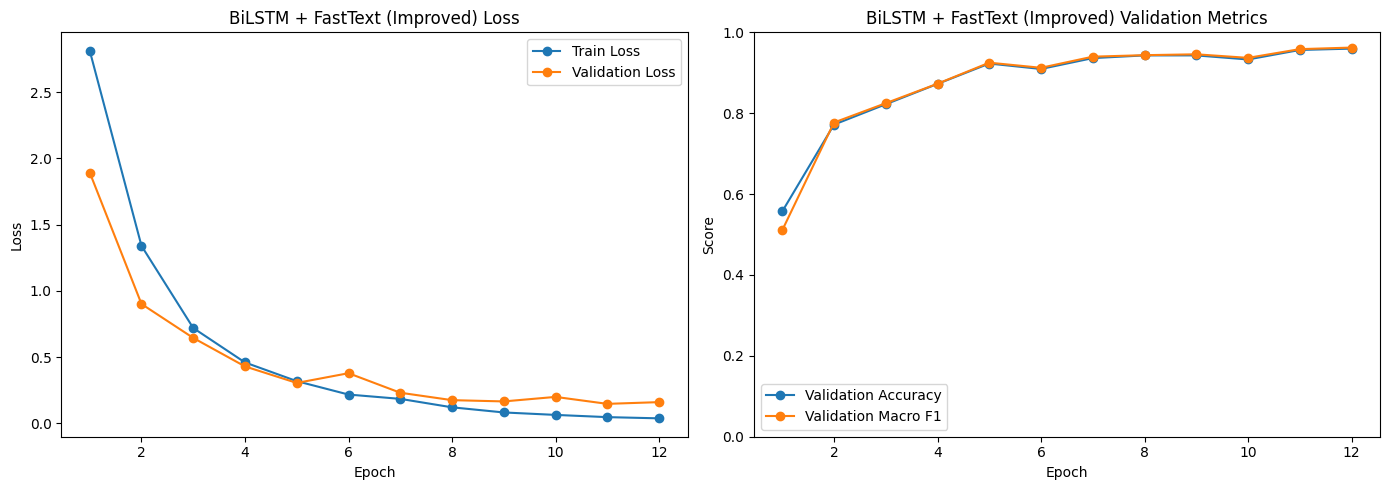

In [ ]:
bilstm_model = BiLSTMClassifier(
    embedding_matrix=embedding_matrix,
    hidden_dim=128,
    output_dim=len(label_encoder.classes_),
    dropout_rate=0.5
)

bilstm_model = bilstm_model.to(device)

bilstm_history = train_bilstm_model(
    bilstm_model,
    train_loader_lstm,
    val_loader_lstm,
    epochs=12,
    learning_rate=0.001,
    patience=3
)

plot_history(bilstm_history, "BiLSTM + FastText (Improved)")

BiLSTM + FastText (Improved)
                                 precision    recall  f1-score   support

                           acne       1.00      1.00      1.00         7
                        allergy       1.00      1.00      1.00        13
                      arthritis       1.00      1.00      1.00        12
               bronchial asthma       0.92      0.92      0.92        13
           cervical spondylosis       1.00      0.92      0.96        13
                    chicken pox       0.71      0.77      0.74        13
                    common cold       0.87      1.00      0.93        13
                         dengue       0.68      1.00      0.81        13
                       diabetes       0.93      1.00      0.97        14
          dimorphic hemorrhoids       1.00      1.00      1.00         6
                  drug reaction       1.00      0.93      0.96        14
               fungal infection       1.00      0.92      0.96        13
gastroesophageal refl

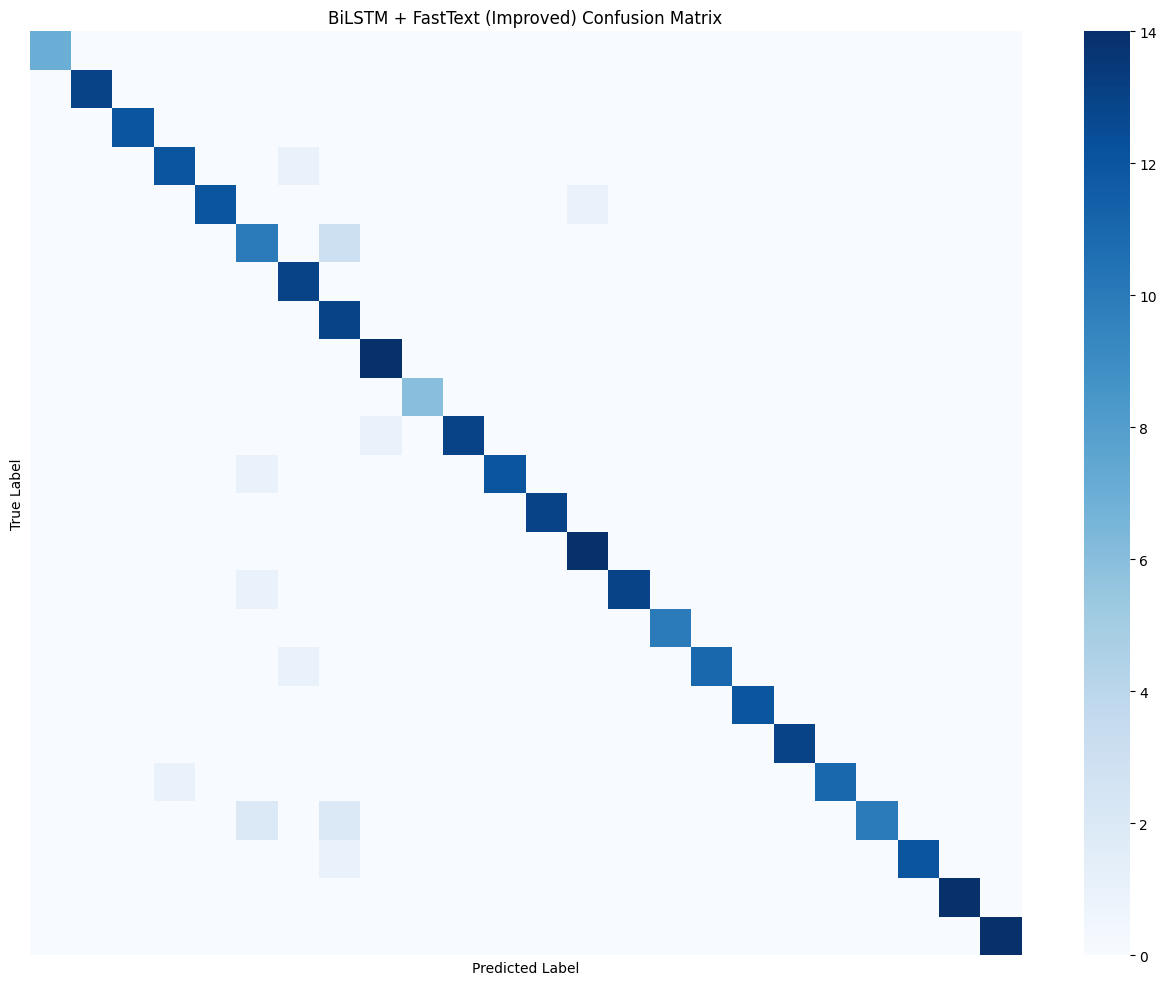

,Model,Text,True Label,Predicted Label
0,BiLSTM + FastText (Improved),"I have a fever, headache, and I can't eat. I f...",chicken pox,dengue
1,BiLSTM + FastText (Improved),I've been experiencing joint pain and skin pee...,psoriasis,dengue
2,BiLSTM + FastText (Improved),I've been having trouble sleeping because of t...,psoriasis,chicken pox
3,BiLSTM + FastText (Improved),"I've been having neck pain, and I've been feel...",cervical spondylosis,hypertension
4,BiLSTM + FastText (Improved),I have been experiencing extreme fatigue and a...,impetigo,chicken pox
5,BiLSTM + FastText (Improved),"On my arms and legs, I have a lot of red pimpl...",fungal infection,chicken pox
6,BiLSTM + FastText (Improved),I am experiencing a lot of nausea and vomiting...,typhoid,dengue
7,BiLSTM + FastText (Improved),"I've had a high fever for the past few days, a...",chicken pox,dengue
8,BiLSTM + FastText (Improved),My skin rash has extended to other areas of my...,psoriasis,chicken pox
9,BiLSTM + FastText (Improved),I've been feeling really sick lately. I've bee...,pneumonia,bronchial asthma


In [ ]:
bilstm_true_labels, bilstm_predictions = predict_bilstm(bilstm_model, test_loader_lstm)

print_model_report(bilstm_true_labels, bilstm_predictions, "BiLSTM + FastText (Improved)")
bilstm_results = calculate_metrics(bilstm_true_labels, bilstm_predictions)
print(bilstm_results)

show_confusion_matrix(bilstm_true_labels, bilstm_predictions, "BiLSTM + FastText (Improved)")

bilstm_wrong_predictions = get_wrong_predictions(
    test_original_texts,
    bilstm_true_labels,
    bilstm_predictions,
    "BiLSTM + FastText (Improved)",
    limit=10
)

bilstm_wrong_predictions

## **DistilBERT (Improved)**

For the transformer models, we use the cleaned full sentence instead of the heavily reduced text. This usually helps BERT-style models because they benefit from full context.

In [ ]:
class TransformerTextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, index):
        encoding = self.tokenizer(
            self.texts[index],
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(self.labels[index], dtype=torch.long)
        }


def create_transformer_loaders(tokenizer, max_length=96, batch_size=8):
    train_dataset = TransformerTextDataset(train_texts_transformer, train_labels, tokenizer, max_length)
    val_dataset = TransformerTextDataset(val_texts_transformer, val_labels, tokenizer, max_length)
    test_dataset = TransformerTextDataset(test_texts_transformer, test_labels, tokenizer, max_length)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size)
    test_loader = DataLoader(test_dataset, batch_size=batch_size)

    return train_loader, val_loader, test_loader

In [ ]:
def train_transformer_model(model, train_loader, val_loader, epochs=4, learning_rate=2e-5, patience=2):
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=0.01)

    history = {'train_loss': [], 'val_loss': [], 'val_accuracy': [], 'val_macro_f1': []}
    best_state = copy.deepcopy(model.state_dict())
    best_val_macro_f1 = -1
    patience_counter = 0

    for epoch in range(epochs):
        model.train()
        total_train_loss = 0

        for batch in tqdm(train_loader, desc=f"Epoch {epoch + 1}"):
            optimizer.zero_grad()

            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            loss = criterion(outputs.logits, labels)
            loss.backward()
            optimizer.step()

            total_train_loss += loss.item()

        model.eval()
        total_val_loss = 0
        val_predictions = []
        val_true_labels = []

        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)

                outputs = model(
                    input_ids=input_ids,
                    attention_mask=attention_mask
                )

                loss = criterion(outputs.logits, labels)
                total_val_loss += loss.item()

                predictions = torch.argmax(outputs.logits, dim=1)
                val_predictions.extend(predictions.cpu().numpy())
                val_true_labels.extend(labels.cpu().numpy())

        val_accuracy = accuracy_score(val_true_labels, val_predictions)
        _, _, val_macro_f1, _ = precision_recall_fscore_support(
            val_true_labels,
            val_predictions,
            average='macro',
            zero_division=0
        )

        history['train_loss'].append(total_train_loss / len(train_loader))
        history['val_loss'].append(total_val_loss / len(val_loader))
        history['val_accuracy'].append(val_accuracy)
        history['val_macro_f1'].append(val_macro_f1)

        print(f"Epoch {epoch + 1}/{epochs} - Train Loss: {history['train_loss'][-1]:.4f} - Validation Loss: {history['val_loss'][-1]:.4f} - Validation Accuracy: {val_accuracy:.4f} - Validation Macro F1: {val_macro_f1:.4f}")

        if val_macro_f1 > best_val_macro_f1:
            best_val_macro_f1 = val_macro_f1
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print("Early stopping was applied.")
            break

    model.load_state_dict(best_state)
    return history


def predict_transformer(model, data_loader):
    model.eval()
    predictions = []
    true_labels = []

    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            batch_predictions = torch.argmax(outputs.logits, dim=1)

            predictions.extend(batch_predictions.cpu().numpy())
            true_labels.extend(labels.cpu().numpy())

    return true_labels, predictions


def run_transformer_experiment(model_name, display_name, max_length=96, batch_size=8, epochs=4, learning_rate=2e-5):
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    train_loader, val_loader, test_loader = create_transformer_loaders(
        tokenizer,
        max_length=max_length,
        batch_size=batch_size
    )

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=len(label_encoder.classes_)
    )

    model = model.to(device)

    history = train_transformer_model(
        model,
        train_loader,
        val_loader,
        epochs=epochs,
        learning_rate=learning_rate,
        patience=2
    )

    plot_history(history, display_name)

    true_labels, predictions = predict_transformer(model, test_loader)

    print_model_report(true_labels, predictions, display_name)
    results = calculate_metrics(true_labels, predictions)
    print(results)

    show_confusion_matrix(true_labels, predictions, display_name)

    wrong_predictions = get_wrong_predictions(
        test_original_texts,
        true_labels,
        predictions,
        display_name,
        limit=10
    )

    del model
    del tokenizer
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return results, history, wrong_predictions, predictions

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Epoch 2/4 - Train Loss: 1.9631 - Validation Loss: 1.3696 - Validation Accuracy: 0.8087 - Validation Macro F1: 0.7987


Epoch 3:   0%|          | 0/87 [00:00<?, ?it/s]

Epoch 3/4 - Train Loss: 1.0756 - Validation Loss: 0.7351 - Validation Accuracy: 0.9295 - Validation Macro F1: 0.9272


Epoch 4:   0%|          | 0/87 [00:00<?, ?it/s]

Epoch 4/4 - Train Loss: 0.5429 - Validation Loss: 0.3743 - Validation Accuracy: 0.9564 - Validation Macro F1: 0.9579


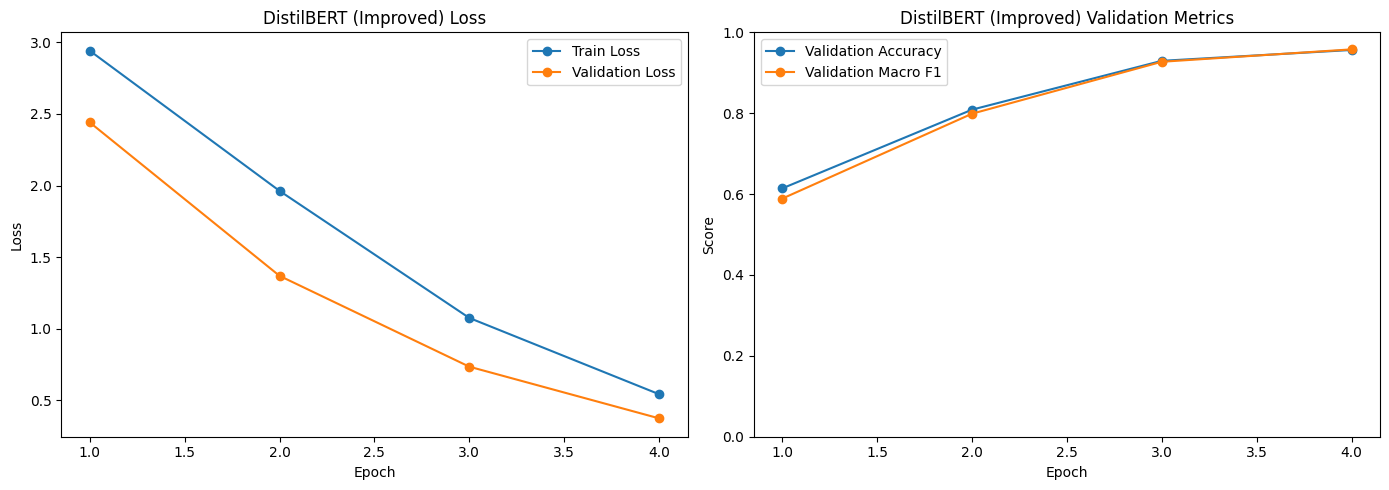

DistilBERT (Improved)
                                 precision    recall  f1-score   support

                           acne       1.00      1.00      1.00         7
                        allergy       1.00      1.00      1.00        13
                      arthritis       0.92      1.00      0.96        12
               bronchial asthma       0.92      0.92      0.92        13
           cervical spondylosis       1.00      1.00      1.00        13
                    chicken pox       1.00      0.69      0.82        13
                    common cold       1.00      1.00      1.00        13
                         dengue       0.75      0.92      0.83        13
                       diabetes       0.82      1.00      0.90        14
          dimorphic hemorrhoids       1.00      1.00      1.00         6
                  drug reaction       1.00      0.71      0.83        14
               fungal infection       1.00      1.00      1.00        13
gastroesophageal reflux dise

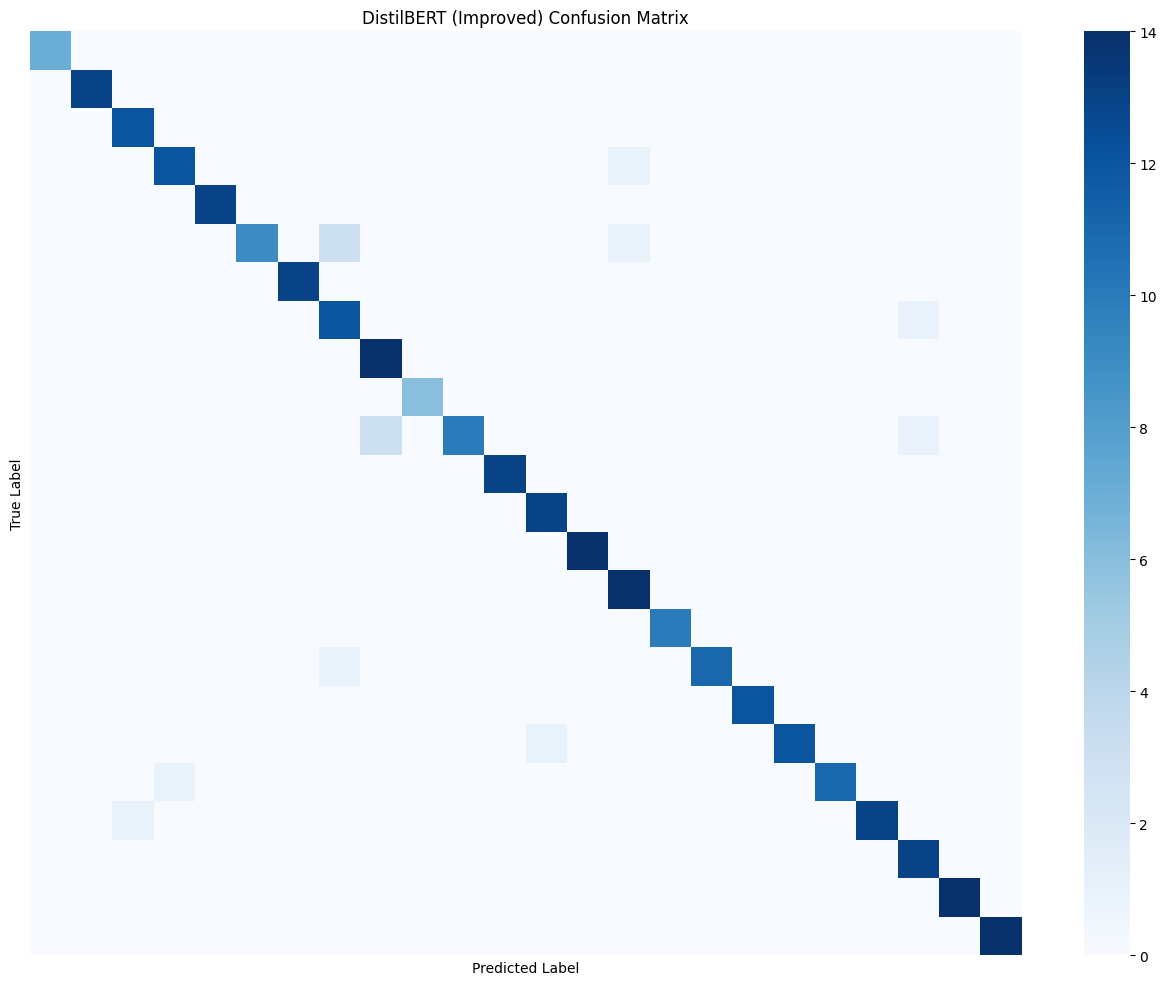

,Model,Text,True Label,Predicted Label
0,DistilBERT (Improved),"Doctor Due to a high fever, I haven't been abl...",bronchial asthma,impetigo
1,DistilBERT (Improved),I have rashes that sometimes peel off my skin....,drug reaction,diabetes
2,DistilBERT (Improved),"I have a fever, headache, and I can't eat. I f...",chicken pox,dengue
3,DistilBERT (Improved),"I suffer migraines and headaches, and I've bee...",drug reaction,diabetes
4,DistilBERT (Improved),I have been feeling nauseous and have a consta...,dengue,typhoid
5,DistilBERT (Improved),I am quite queasy and dizzy when I have a temp...,drug reaction,diabetes
6,DistilBERT (Improved),"I've had a high fever for the past few days, a...",chicken pox,dengue
7,DistilBERT (Improved),I've been feeling really sick lately. I've bee...,pneumonia,bronchial asthma
8,DistilBERT (Improved),I have red spots on my arms and legs and itchi...,chicken pox,dengue
9,DistilBERT (Improved),I have been experiencing a lot of fatigue and ...,psoriasis,arthritis


In [ ]:
distilbert_results, distilbert_history, distilbert_wrong_predictions, distilbert_predictions = run_transformer_experiment(
    model_name="distilbert-base-uncased",
    display_name="DistilBERT (Improved)",
    max_length=96,
    batch_size=16,
    epochs=4,
    learning_rate=2e-5
)

distilbert_wrong_predictions

## **Bio_ClinicalBERT**

This model is a stronger medical candidate because it was pre-trained on clinical notes. That makes it a reasonable model for symptom descriptions written in natural language.

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

...

Epoch 2/4 - Train Loss: 1.4839 - Validation Loss: 0.8793 - Validation Accuracy: 0.8624 - Validation Macro F1: 0.8632


Epoch 3:   0%|          | 0/174 [00:00<?, ?it/s]

Epoch 3/4 - Train Loss: 0.6165 - Validation Loss: 0.3905 - Validation Accuracy: 0.9530 - Validation Macro F1: 0.9559


Epoch 4:   0%|          | 0/174 [00:00<?, ?it/s]

Epoch 4/4 - Train Loss: 0.2701 - Validation Loss: 0.1825 - Validation Accuracy: 0.9832 - Validation Macro F1: 0.9843


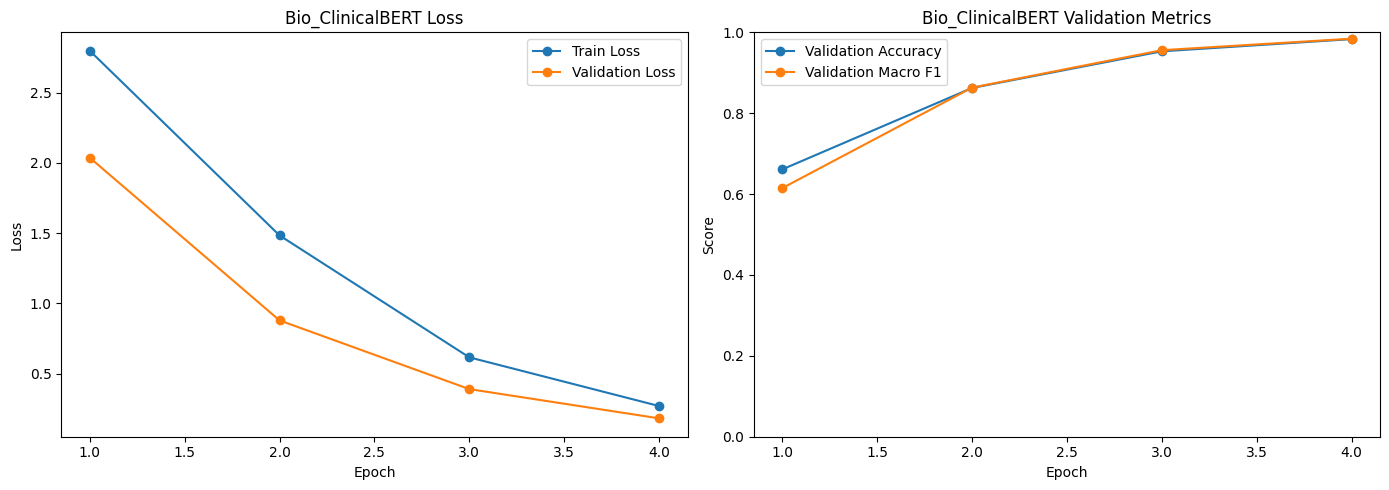

Bio_ClinicalBERT
                                 precision    recall  f1-score   support

                           acne       1.00      1.00      1.00         7
                        allergy       1.00      1.00      1.00        13
                      arthritis       0.92      1.00      0.96        12
               bronchial asthma       1.00      0.92      0.96        13
           cervical spondylosis       1.00      1.00      1.00        13
                    chicken pox       0.93      1.00      0.96        13
                    common cold       0.93      1.00      0.96        13
                         dengue       1.00      0.92      0.96        13
                       diabetes       1.00      1.00      1.00        14
          dimorphic hemorrhoids       1.00      1.00      1.00         6
                  drug reaction       1.00      1.00      1.00        14
               fungal infection       1.00      1.00      1.00        13
gastroesophageal reflux disease  

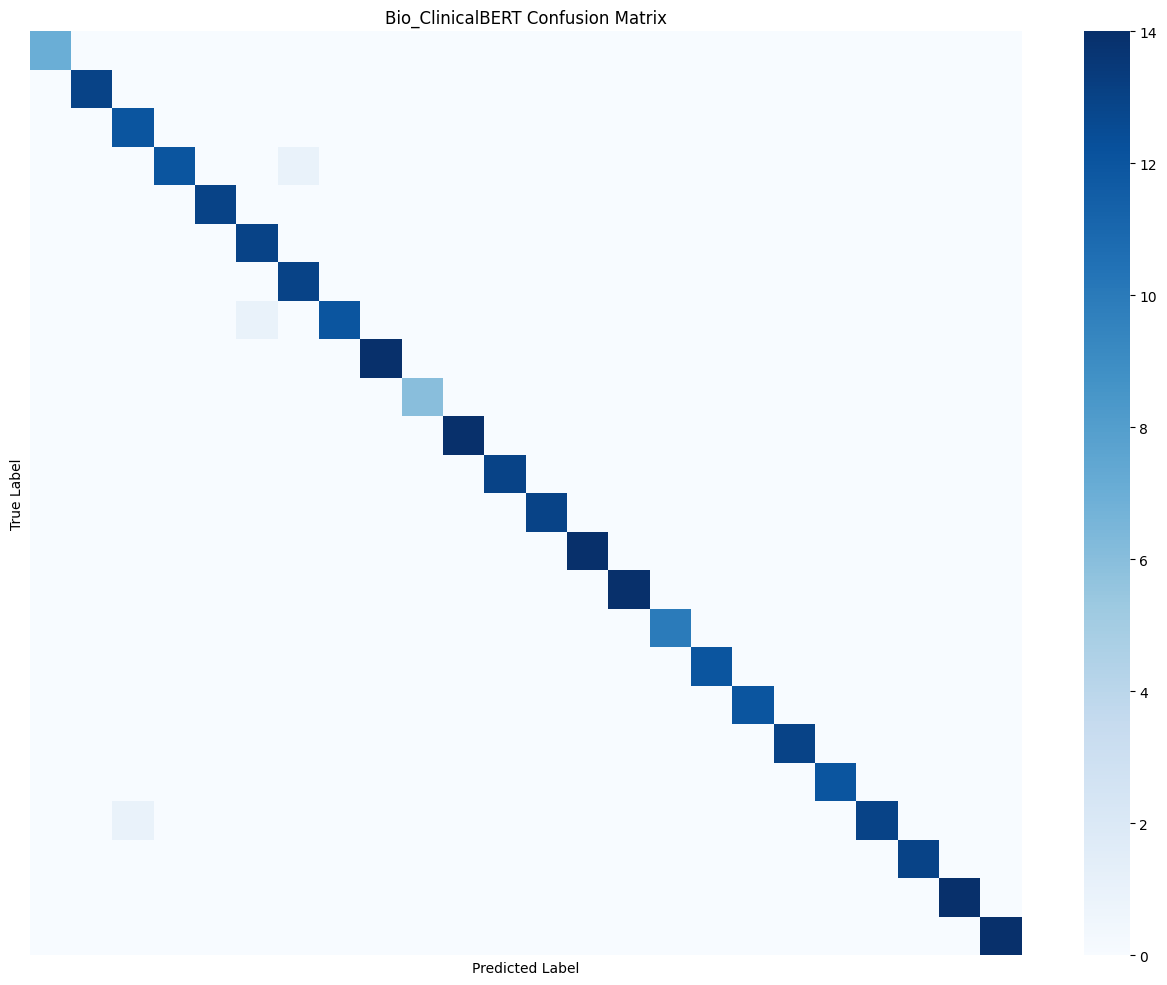

,Model,Text,True Label,Predicted Label
0,Bio_ClinicalBERT,"Doctor Due to a high fever, I haven't been abl...",bronchial asthma,common cold
1,Bio_ClinicalBERT,I have been experiencing a lot of fatigue and ...,psoriasis,arthritis
2,Bio_ClinicalBERT,I have developed rashes all over my body that ...,dengue,chicken pox


In [ ]:
bio_clinicalbert_results, bio_clinicalbert_history, bio_clinicalbert_wrong_predictions, bio_clinicalbert_predictions = run_transformer_experiment(
    model_name="emilyalsentzer/Bio_ClinicalBERT",
    display_name="Bio_ClinicalBERT",
    max_length=96,
    batch_size=8,
    epochs=4,
    learning_rate=2e-5
)

bio_clinicalbert_wrong_predictions

## **BiomedBERT**

This model is another strong medical candidate because it was pre-trained from scratch on biomedical text. It is often stronger than general-domain BERT models on biomedical tasks.

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

Epoch 2/4 - Train Loss: 0.9891 - Validation Loss: 0.5023 - Validation Accuracy: 0.9262 - Validation Macro F1: 0.9191


Epoch 3:   0%|          | 0/174 [00:00<?, ?it/s]

Epoch 3/4 - Train Loss: 0.3558 - Validation Loss: 0.2127 - Validation Accuracy: 0.9698 - Validation Macro F1: 0.9710


Epoch 4:   0%|          | 0/174 [00:00<?, ?it/s]

Epoch 4/4 - Train Loss: 0.1530 - Validation Loss: 0.1164 - Validation Accuracy: 0.9832 - Validation Macro F1: 0.9843


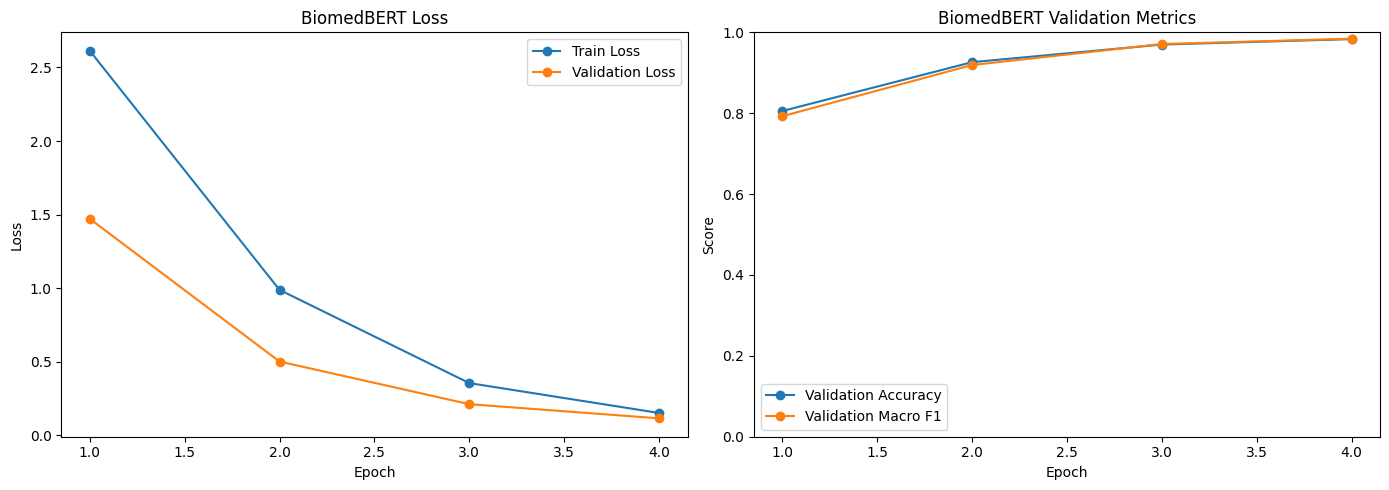

BiomedBERT
                                 precision    recall  f1-score   support

                           acne       1.00      1.00      1.00         7
                        allergy       0.93      1.00      0.96        13
                      arthritis       1.00      1.00      1.00        12
               bronchial asthma       1.00      0.92      0.96        13
           cervical spondylosis       1.00      1.00      1.00        13
                    chicken pox       1.00      0.69      0.82        13
                    common cold       1.00      1.00      1.00        13
                         dengue       0.76      1.00      0.87        13
                       diabetes       1.00      0.86      0.92        14
          dimorphic hemorrhoids       1.00      1.00      1.00         6
                  drug reaction       0.88      1.00      0.93        14
               fungal infection       1.00      1.00      1.00        13
gastroesophageal reflux disease       1

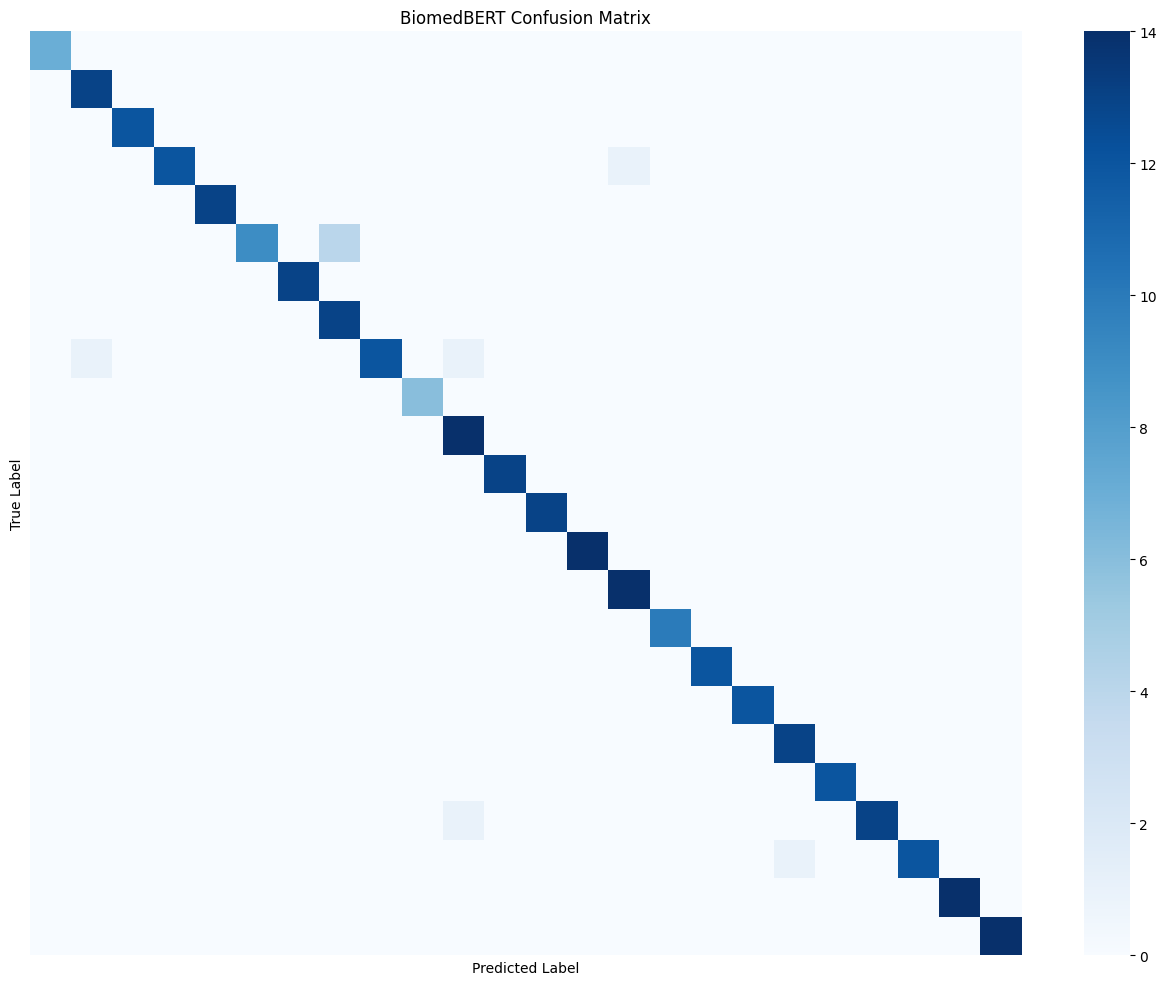

,Model,Text,True Label,Predicted Label
0,BiomedBERT,"Doctor Due to a high fever, I haven't been abl...",bronchial asthma,impetigo
1,BiomedBERT,"I have a fever, headache, and I can't eat. I f...",chicken pox,dengue
2,BiomedBERT,My entire body is trembling and shaky. I've lo...,diabetes,allergy
3,BiomedBERT,"My emotions change, and I have difficulties fo...",diabetes,drug reaction
4,BiomedBERT,I am feeling quite weak. I'm having a lot of s...,typhoid,peptic ulcer disease
5,BiomedBERT,"I've had a high fever for the past few days, a...",chicken pox,dengue
6,BiomedBERT,I have red spots on my arms and legs and itchi...,chicken pox,dengue
7,BiomedBERT,I have been experiencing a lot of fatigue and ...,psoriasis,drug reaction
8,BiomedBERT,My skin rash is giving me a lot of pain and di...,chicken pox,dengue


In [ ]:
biomedbert_results, biomedbert_history, biomedbert_wrong_predictions, biomedbert_predictions = run_transformer_experiment(
    model_name="microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract-fulltext",
    display_name="BiomedBERT",
    max_length=96,
    batch_size=8,
    epochs=4,
    learning_rate=2e-5
)

biomedbert_wrong_predictions

## **Model comparison**

In [ ]:
comparison_table = pd.DataFrame([
    {'Model': 'BiLSTM + FastText (Improved)', 'Group': 'Base Models', **bilstm_results},
    {'Model': 'DistilBERT (Improved)', 'Group': 'Base Models', **distilbert_results},
    {'Model': 'Bio_ClinicalBERT', 'Group': 'Additional Models', **bio_clinicalbert_results},
    {'Model': 'BiomedBERT', 'Group': 'Additional Models', **biomedbert_results}
])

comparison_table = comparison_table.sort_values('Macro F1', ascending=False).reset_index(drop=True)
comparison_table = comparison_table.round(4)
comparison_table

,Model,Group,Accuracy,Weighted Precision,Weighted Recall,Weighted F1,Macro Precision,Macro Recall,Macro F1
0,Bio_ClinicalBERT,Additional Models,0.9900,0.9907,0.9900,0.9900,0.9908,0.9906,0.9904
1,BiomedBERT,Additional Models,0.9699,0.9746,0.9699,0.9695,0.9763,0.9718,0.9715
2,DistilBERT (Improved),Base Models,0.9532,0.9597,0.9532,0.9525,0.9621,0.9557,0.9553
3,BiLSTM + FastText (Improved),Base Models,0.9498,0.9585,0.9498,0.9509,0.9606,0.9528,0.9537


In [ ]:
output_comparison_table = pd.DataFrame({
    'Text': test_original_texts[:10],
    'True Label': label_encoder.inverse_transform(np.array(test_labels[:10])),
    'BiLSTM + FastText (Improved)': label_encoder.inverse_transform(np.array(bilstm_predictions[:10])),
    'DistilBERT (Improved)': label_encoder.inverse_transform(np.array(distilbert_predictions[:10])),
    'Bio_ClinicalBERT': label_encoder.inverse_transform(np.array(bio_clinicalbert_predictions[:10])),
    'BiomedBERT': label_encoder.inverse_transform(np.array(biomedbert_predictions[:10]))
})

output_comparison_table

,Text,True Label,BiLSTM + FastText (Improved),DistilBERT (Improved),Bio_ClinicalBERT,BiomedBERT
0,"Doctor Due to a high fever, I haven't been abl...",bronchial asthma,bronchial asthma,impetigo,common cold,impetigo
1,I have to pee a lot and I'm always hungry. I g...,diabetes,diabetes,diabetes,diabetes,diabetes
2,Along with a phlegmy cough and muscle weakness...,cervical spondylosis,cervical spondylosis,cervical spondylosis,cervical spondylosis,cervical spondylosis
3,"I have a sour taste in my mouth all the time, ...",gastroesophageal reflux disease,gastroesophageal reflux disease,gastroesophageal reflux disease,gastroesophageal reflux disease,gastroesophageal reflux disease
4,I have been losing weight and having trouble g...,peptic ulcer disease,peptic ulcer disease,peptic ulcer disease,peptic ulcer disease,peptic ulcer disease
5,I have rashes that sometimes peel off my skin....,drug reaction,drug reaction,diabetes,drug reaction,drug reaction
6,There are small red spots all over my body tha...,chicken pox,chicken pox,chicken pox,chicken pox,chicken pox
7,I developed a minor rash near my nose a few da...,impetigo,impetigo,impetigo,impetigo,impetigo
8,"I have a sour taste in my mouth all the time, ...",gastroesophageal reflux disease,gastroesophageal reflux disease,gastroesophageal reflux disease,gastroesophageal reflux disease,gastroesophageal reflux disease
9,I have been having a high fever for the past f...,typhoid,typhoid,typhoid,typhoid,typhoid


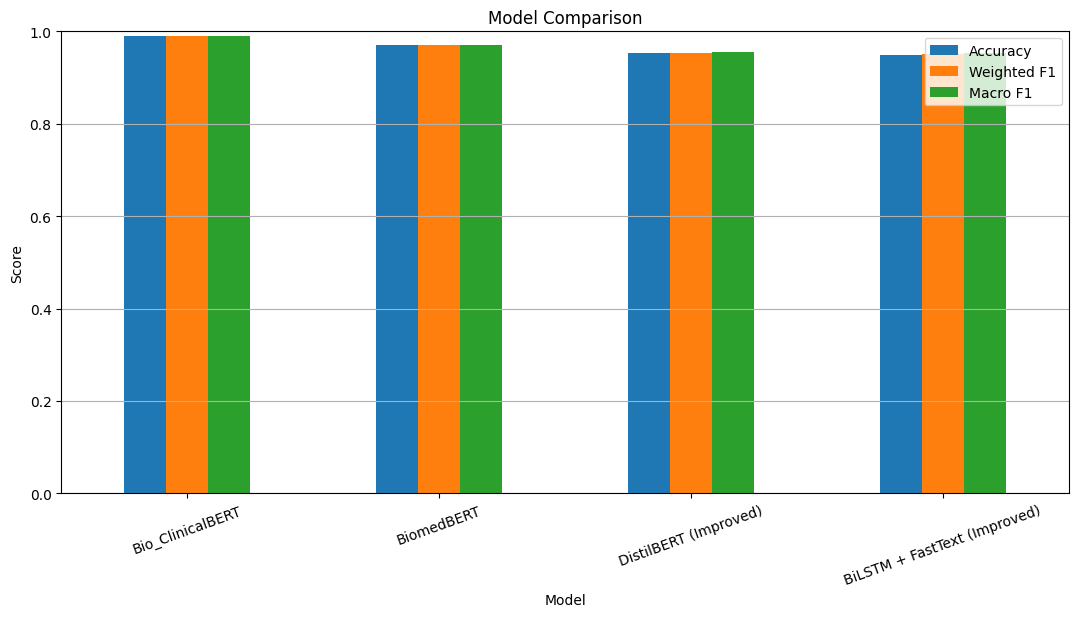

In [ ]:
comparison_plot = comparison_table.set_index('Model')[['Accuracy', 'Weighted F1', 'Macro F1']]

comparison_plot.plot(kind='bar', figsize=(13, 6))
plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=20)
plt.ylim(0, 1)
plt.grid(axis='y')
plt.show()

In [ ]:
best_base_model = comparison_table[comparison_table['Group'] == 'Base Models'].sort_values('Macro F1', ascending=False).iloc[0]
best_overall_model = comparison_table.sort_values('Macro F1', ascending=False).iloc[0]

print("Best base model based on Macro F1:", best_base_model['Model'])
print("Best overall model based on Macro F1:", best_overall_model['Model'])

Best base model based on Macro F1: DistilBERT (Improved)
Best overall model based on Macro F1: Bio_ClinicalBERT


## **Misclassifications and qualitative comparison**

In [ ]:
print("BiLSTM + FastText (Improved) wrong predictions")
display(bilstm_wrong_predictions)

print("DistilBERT (Improved) wrong predictions")
display(distilbert_wrong_predictions)

print("Bio_ClinicalBERT wrong predictions")
display(bio_clinicalbert_wrong_predictions)

print("BiomedBERT wrong predictions")
display(biomedbert_wrong_predictions)

BiLSTM + FastText (Improved) wrong predictions


,Model,Text,True Label,Predicted Label
0,BiLSTM + FastText (Improved),"I have a fever, headache, and I can't eat. I f...",chicken pox,dengue
1,BiLSTM + FastText (Improved),I've been experiencing joint pain and skin pee...,psoriasis,dengue
2,BiLSTM + FastText (Improved),I've been having trouble sleeping because of t...,psoriasis,chicken pox
3,BiLSTM + FastText (Improved),"I've been having neck pain, and I've been feel...",cervical spondylosis,hypertension
4,BiLSTM + FastText (Improved),I have been experiencing extreme fatigue and a...,impetigo,chicken pox
5,BiLSTM + FastText (Improved),"On my arms and legs, I have a lot of red pimpl...",fungal infection,chicken pox
6,BiLSTM + FastText (Improved),I am experiencing a lot of nausea and vomiting...,typhoid,dengue
7,BiLSTM + FastText (Improved),"I've had a high fever for the past few days, a...",chicken pox,dengue
8,BiLSTM + FastText (Improved),My skin rash has extended to other areas of my...,psoriasis,chicken pox
9,BiLSTM + FastText (Improved),I've been feeling really sick lately. I've bee...,pneumonia,bronchial asthma


DistilBERT (Improved) wrong predictions


,Model,Text,True Label,Predicted Label
0,DistilBERT (Improved),"Doctor Due to a high fever, I haven't been abl...",bronchial asthma,impetigo
1,DistilBERT (Improved),I have rashes that sometimes peel off my skin....,drug reaction,diabetes
2,DistilBERT (Improved),"I have a fever, headache, and I can't eat. I f...",chicken pox,dengue
3,DistilBERT (Improved),"I suffer migraines and headaches, and I've bee...",drug reaction,diabetes
4,DistilBERT (Improved),I have been feeling nauseous and have a consta...,dengue,typhoid
5,DistilBERT (Improved),I am quite queasy and dizzy when I have a temp...,drug reaction,diabetes
6,DistilBERT (Improved),"I've had a high fever for the past few days, a...",chicken pox,dengue
7,DistilBERT (Improved),I've been feeling really sick lately. I've bee...,pneumonia,bronchial asthma
8,DistilBERT (Improved),I have red spots on my arms and legs and itchi...,chicken pox,dengue
9,DistilBERT (Improved),I have been experiencing a lot of fatigue and ...,psoriasis,arthritis


Bio_ClinicalBERT wrong predictions


,Model,Text,True Label,Predicted Label
0,Bio_ClinicalBERT,"Doctor Due to a high fever, I haven't been abl...",bronchial asthma,common cold
1,Bio_ClinicalBERT,I have been experiencing a lot of fatigue and ...,psoriasis,arthritis
2,Bio_ClinicalBERT,I have developed rashes all over my body that ...,dengue,chicken pox


BiomedBERT wrong predictions


,Model,Text,True Label,Predicted Label
0,BiomedBERT,"Doctor Due to a high fever, I haven't been abl...",bronchial asthma,impetigo
1,BiomedBERT,"I have a fever, headache, and I can't eat. I f...",chicken pox,dengue
2,BiomedBERT,My entire body is trembling and shaky. I've lo...,diabetes,allergy
3,BiomedBERT,"My emotions change, and I have difficulties fo...",diabetes,drug reaction
4,BiomedBERT,I am feeling quite weak. I'm having a lot of s...,typhoid,peptic ulcer disease
5,BiomedBERT,"I've had a high fever for the past few days, a...",chicken pox,dengue
6,BiomedBERT,I have red spots on my arms and legs and itchi...,chicken pox,dengue
7,BiomedBERT,I have been experiencing a lot of fatigue and ...,psoriasis,drug reaction
8,BiomedBERT,My skin rash is giving me a lot of pain and di...,chicken pox,dengue


The final decision should be based mainly on `Macro F1`, because the dataset is not perfectly balanced.

Expected interpretation:
- If a medical-domain transformer gives the highest Macro F1, then domain-specific pretraining helped the most.
- If `DistilBERT (Improved)` stays close to the best score, then it remains a good lighter model.
- `BiLSTM + FastText (Improved)` is still useful as a simpler deep learning baseline, but transformer models will usually capture more context.